In [37]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
T = 252
annual_mu = 0.10
annual_vol = 0.05
daily_mu = annual_mu/T
daily_vol = annual_vol/np.sqrt(T)
n_simulations = 10_000

print(daily_mu)
print(daily_vol)


0.0003968253968253968
0.00314970394174356


In [39]:
returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )
# each row is one simulated year path
# each col is one trading day
# size is n_simulations * T

In [40]:
wealth = 100 * (1+returns).cumprod(axis=1)
wealth

array([[100.49787297, 100.3349373 , 100.50598049, ..., 110.99038905,
        111.32812035, 110.90130868],
       [100.28218128, 100.72632104, 101.18249428, ..., 111.33216071,
        111.13735289, 111.10275517],
       [100.49148328, 100.15818389,  99.72678432, ..., 103.82478456,
        103.71315177, 104.00077485],
       ...,
       [ 99.99844725, 100.21432968, 100.20010092, ..., 118.34162626,
        118.46320706, 118.29404014],
       [ 99.50536891,  99.81111291, 100.08401889, ..., 110.76325177,
        111.00085519, 111.40148483],
       [100.62218883, 100.31465489, 100.56773374, ..., 111.77312228,
        111.53708647, 112.16824695]], shape=(10000, 252))

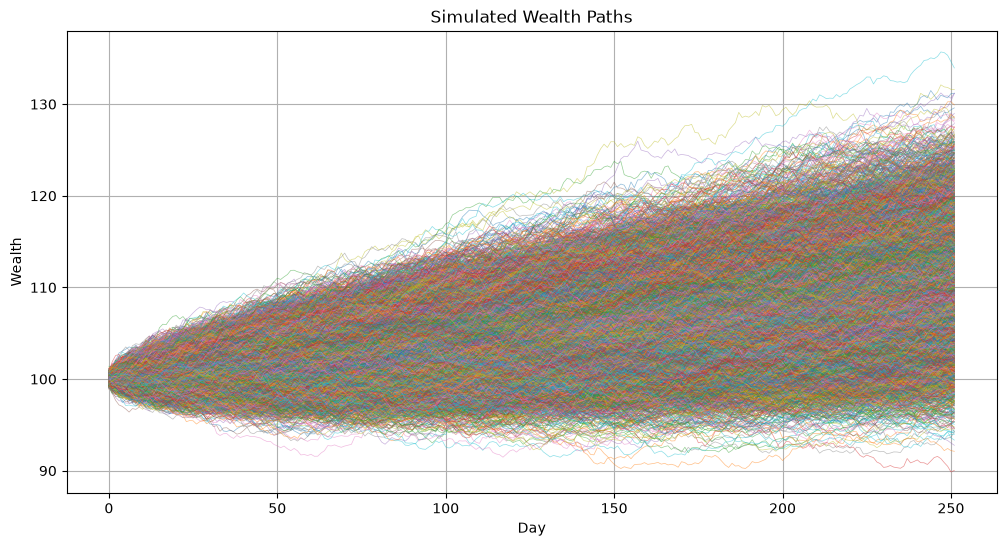

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(wealth.T, alpha=0.5, linewidth=0.5)

plt.xlabel("Day")
plt.ylabel("Wealth")
plt.title("Simulated Wealth Paths")
plt.grid(True)

plt.show()

In [42]:
T = 252

annual_mu = 0.10

daily_mu = annual_mu / T

vols = [0.05, 0.10, 0.20, 0.30, 0.50]

n_simulations = 10_000


results = []

for annual_vol in vols:

    daily_vol = annual_vol / np.sqrt(252)

    returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )

    wealth = 100 * np.prod(1 + returns, axis=1)

    
    percentiles = np.percentile(wealth,[25,50,75])

    results.append({
        "vol": annual_vol,
        "mean_wealth": wealth.mean(),
        "25th percentile wealth": percentiles[0],
        "50th percentile wealth": percentiles[1],
        "75th percentile wealth": percentiles[2],
        "mean_log_growth": np.mean(
            np.sum(np.log1p(returns), axis=1)
        )
    })

In [43]:
results

[{'vol': 0.05,
  'mean_wealth': np.float64(110.54278484889106),
  '25th percentile wealth': np.float64(106.69701440131027),
  '50th percentile wealth': np.float64(110.30952663808148),
  '75th percentile wealth': np.float64(114.23100411922576),
  'mean_log_growth': np.float64(0.09898133900626269)},
 {'vol': 0.1,
  'mean_wealth': np.float64(110.5417733740407),
  '25th percentile wealth': np.float64(102.7206173875123),
  '50th percentile wealth': np.float64(109.93595828667267),
  '75th percentile wealth': np.float64(117.68109535901888),
  'mean_log_growth': np.float64(0.0952467090213233)},
 {'vol': 0.2,
  'mean_wealth': np.float64(110.23319404762817),
  '25th percentile wealth': np.float64(94.3975977123386),
  '50th percentile wealth': np.float64(108.09371630425467),
  '75th percentile wealth': np.float64(123.73491567620208),
  'mean_log_growth': np.float64(0.07759925238033638)},
 {'vol': 0.3,
  'mean_wealth': np.float64(110.65127208171114),
  '25th percentile wealth': np.float64(86.53573

In [44]:
from RPG import ReturnPathGenerator

In [45]:
T = 252
annual_vol = 0.10

mus = [0.05, 0.10, 0.20, 0.30, 0.50]

n_simulations = 10_000


results = []

for annual_mu in mus:

    model = ReturnPathGenerator(annual_mu=annual_mu,annual_vol=annual_vol,no_periods=T)

    model.get_return_path(n_simulations=10_000, horizon=252)
    summary = model.summary_statistics(starting_wealth=100)

    print(f"Annual mean return: {annual_mu}, Annual vol: {annual_vol}")

    for key, value in summary.items():
        print(f"{key}: {value:.4f}")

    print()

Annual mean return: 0.05, Annual vol: 0.1
mean_wealth: 105.1569
25th percentile wealth: 97.7187
50th percentile wealth: 104.6816
75th percentile wealth: 112.0255
mean_log_growth: 0.0453

Annual mean return: 0.1, Annual vol: 0.1
mean_wealth: 110.4588
25th percentile wealth: 102.7349
50th percentile wealth: 109.8913
75th percentile wealth: 117.5398
mean_log_growth: 0.0945

Annual mean return: 0.2, Annual vol: 0.1
mean_wealth: 121.9826
25th percentile wealth: 113.5042
50th percentile wealth: 121.2941
75th percentile wealth: 129.9047
mean_log_growth: 0.1937

Annual mean return: 0.3, Annual vol: 0.1
mean_wealth: 134.9385
25th percentile wealth: 125.3617
50th percentile wealth: 134.0562
75th percentile wealth: 143.7085
mean_log_growth: 0.2946

Annual mean return: 0.5, Annual vol: 0.1
mean_wealth: 164.8749
25th percentile wealth: 153.2015
50th percentile wealth: 164.1139
75th percentile wealth: 175.4831
mean_log_growth: 0.4950

